### Trying SVMS on the Iris dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

In [2]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]]
y = (iris.target == 2) #Iris Virginica

svm_clf= make_pipeline(
    StandardScaler(),
    LinearSVC(C=1, loss = 'hinge')
)

In [3]:
svm_clf.fit(X,y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(C=1, loss='hinge'))])

In [4]:
X_new = [[5.5,1.7], [5.0,1.5]]
svm_clf.predict(X_new)

C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([ True, False])

In [5]:
svm_clf.decision_function(X_new) # This is the signed distance between the instance and decision boundary

C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([ 0.68566206, -0.40719481])

In [6]:
X["petal length (cm)"].describe()

count    150.000000
mean       3.758000
std        1.765298
min        1.000000
25%        1.600000
50%        4.350000
75%        5.100000
max        6.900000
Name: petal length (cm), dtype: float64

In [7]:
X["petal width (cm)"].describe()

count    150.000000
mean       1.199333
std        0.762238
min        0.100000
25%        0.300000
50%        1.300000
75%        1.800000
max        2.500000
Name: petal width (cm), dtype: float64

In [8]:
X

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


In [10]:
x_min = X.iloc[:,0].min() - 0.2
x_max = X.iloc[:,0].max() + 0.2

y_min = X.iloc[:,1].min() - 0.2
y_max = X.iloc[:,1].max() + 0.2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

X_new = np.c_[xx.ravel(), yy.ravel()]

In [11]:
decision = svm_clf.decision_function(X_new)
decision = decision.reshape(xx.shape)

C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [12]:
decision

array([[-9.33572215, -9.32400135, -9.31228054, ..., -3.51048331,
        -3.49876251, -3.48704171],
       [-9.31808395, -9.30636315, -9.29464234, ..., -3.49284511,
        -3.48112431, -3.46940351],
       [-9.30044575, -9.28872494, -9.27700414, ..., -3.47520691,
        -3.46348611, -3.45176531],
       ...,
       [-0.56953622, -0.55781542, -0.54609461, ...,  5.25570262,
         5.26742342,  5.27914422],
       [-0.55189802, -0.54017721, -0.52845641, ...,  5.27334082,
         5.28506162,  5.29678242],
       [-0.53425982, -0.52253901, -0.51081821, ...,  5.29097902,
         5.30269982,  5.31442062]])

In [13]:
decision.shape

(500, 500)

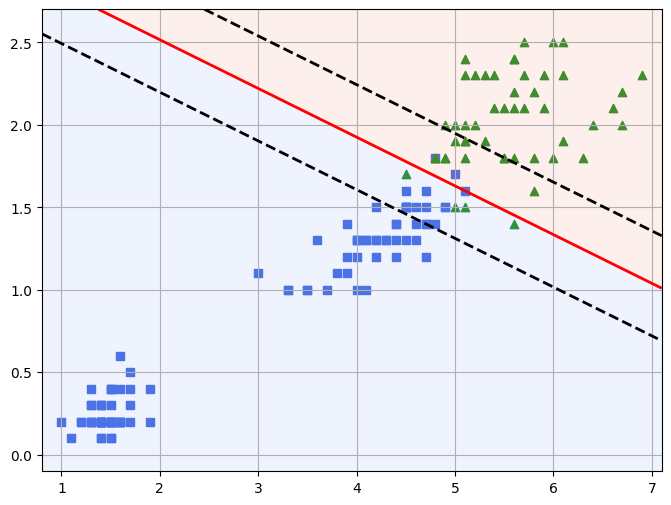

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    X.loc[~y, "petal length (cm)"],
    X.loc[~y, "petal width (cm)"],
    c="royalblue",
    marker="s",
    label="Not Virginica"
)

plt.scatter(
    X.loc[y, "petal length (cm)"],
    X.loc[y, "petal width (cm)"],
    c="forestgreen",
    marker="^",
    label="Virginica"
)

plt.contour(
    xx,
    yy,
    decision,
    levels=[-1, 0, 1],
    colors=["black", "red", "black"],
    linestyles=["--", "-", "--"],
    linewidths=2
)

plt.contourf(
    xx,
    yy,
    decision > 0,
    alpha=0.15,
    cmap="coolwarm"
)

plt.grid()

In [15]:
def plot_svm(clf, X, y, ax= None):
    """
    Plot the decision boundary and margins of a trained linear SVM.

    Parameters
    ----------
    clf : fitted Pipeline (StandardScaler -> LinearSVC)
    X   : DataFrame with exactly 2 features
    y   : Boolean/0-1 labels
    ax  : matplotlib axis
    """

    # -----------------------
    # Create meshgrid
    # -----------------------
    x_min = X.iloc[:, 0].min() - 0.2
    x_max = X.iloc[:, 0].max() + 0.2

    y_min = X.iloc[:, 1].min() - 0.2
    y_max = X.iloc[:, 1].max() + 0.2

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    X_new = np.c_[xx.ravel(), yy.ravel()]

    # -----------------------
    # Decision function
    # -----------------------
    decision = clf.decision_function(X_new)
    decision = decision.reshape(xx.shape)

    # -----------------------
    # Background colouring
    # -----------------------
    ax.contourf(
        xx,
        yy,
        decision > 0,
        alpha=0.20,
        cmap="coolwarm"
    )

    # -----------------------
    # Decision boundary
    # -----------------------
    ax.contour(
        xx,
        yy,
        decision,
        levels=[-1, 0, 1],
        colors=["black", "red", "black"],
        linestyles=["--", "-", "--"],
        linewidths=2
    )

    # -----------------------
    # Plot data
    # -----------------------
    ax.scatter(
        X.loc[~y].iloc[:, 0],
        X.loc[~y].iloc[:, 1],
        c="royalblue",
        marker="s",
        edgecolor="k",
        label="Class 0"
    )

    ax.scatter(
        X.loc[y].iloc[:, 0],
        X.loc[y].iloc[:, 1],
        c="forestgreen",
        marker="^",
        edgecolor="k",
        label="Class 1"
    )

    ax.set_xlabel(X.columns[0])
    ax.set_ylabel(X.columns[1])

    ax.grid(True)

C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


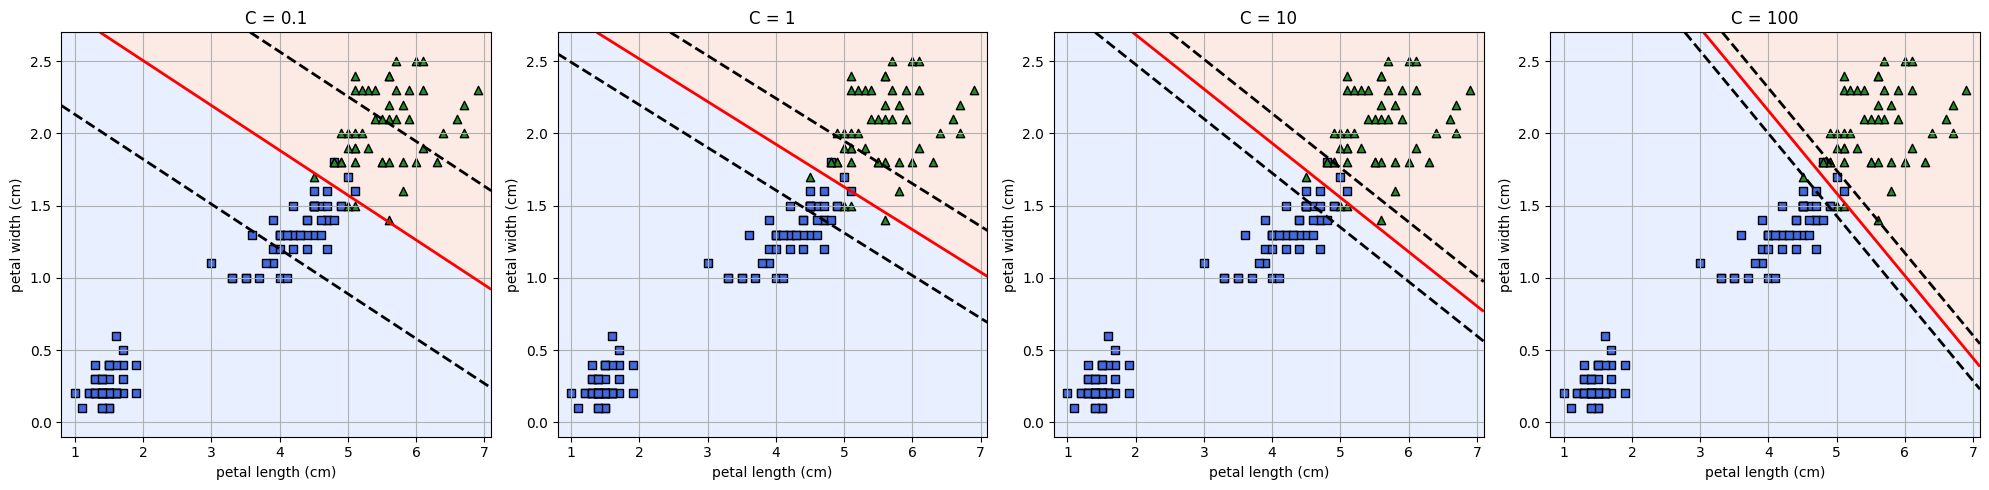

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
Cs= [0.1, 1, 10, 100]

for ax, C in zip(axes, Cs):

    svm = make_pipeline(
        StandardScaler(),
        LinearSVC(C=C, loss="hinge")
    )

    svm.fit(X, y)

    plot_svm(svm, X, y, ax),
    ax.set_title(f"C = {C}")

plt.tight_layout()

*As you can see, beyond just the margin shortening (as we inc C), the seperating hyperplane itself changes, reason being it depends solely on the **support vectors** present between itself and it's margin*

### Non Linear SVMS

In [17]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

X,y = make_moons(n_samples= 100, noise= 0.15, random_state= 42)

polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree = 3),
    StandardScaler(),
    LinearSVC(C=10, max_iter= 10_000, random_state= 42)
)

polynomial_svm_clf.fit(X,y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('standardscaler', StandardScaler()),
                ('linearsvc',
                 LinearSVC(C=10, max_iter=10000, random_state=42))])

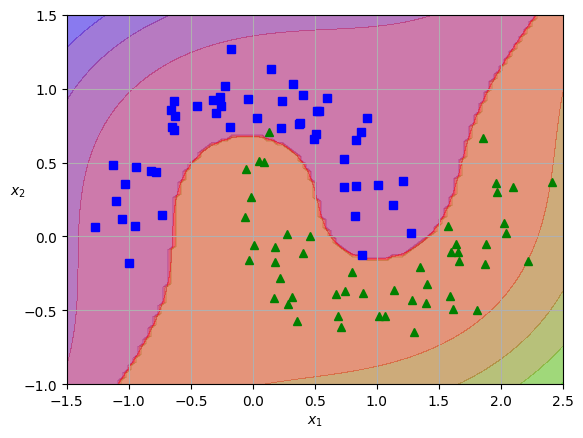

In [44]:
import matplotlib.pyplot as plt

def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2 )
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg,  alpha=0.4)

plot_predictions(polynomial_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])


In [56]:
from sklearn.svm import SVC

poly_kernel_svc_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="poly", C=5)
)



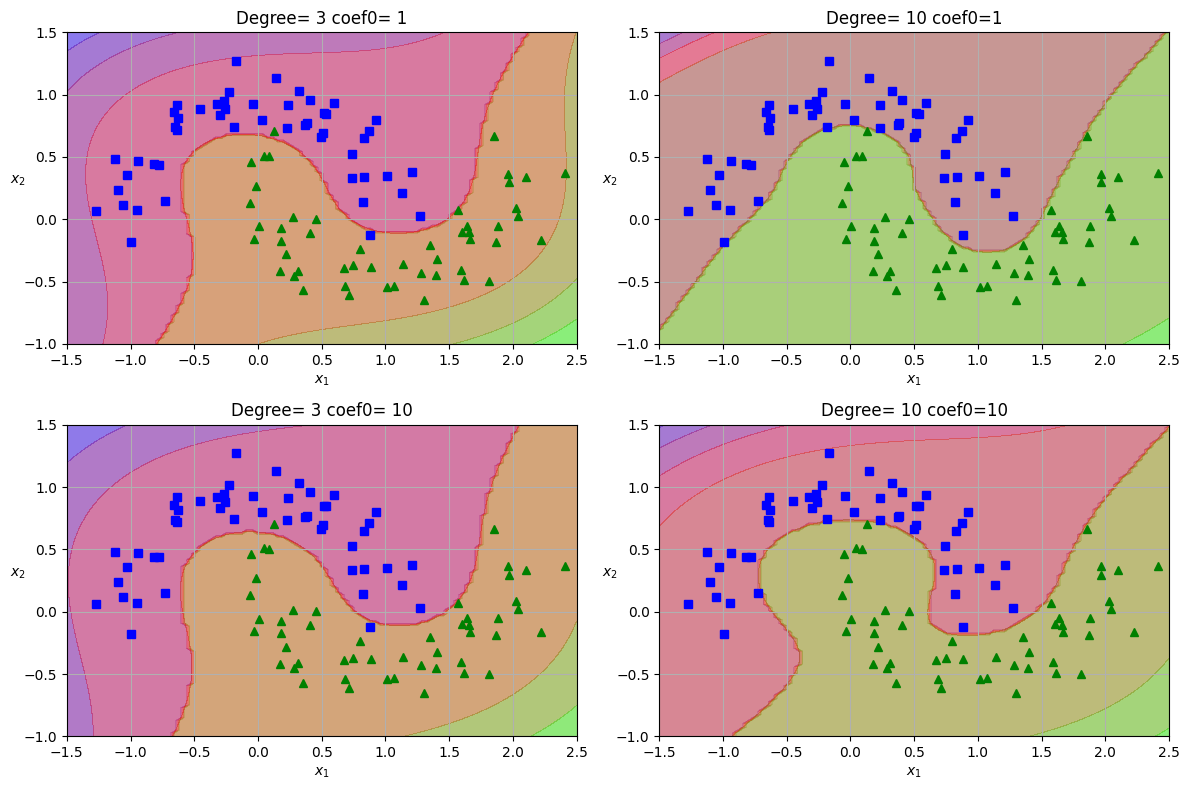

In [74]:
fig, axes= plt.subplots(2, 2, figsize= (12,8))

plt.sca(axes[0][0])
poly_kernel_svc_clf.set_params(svc__degree=3, svc__coef0=1)
poly_kernel_svc_clf.fit(X, y)
plot_predictions(poly_kernel_svc_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title("Degree= 3 coef0= 1")

plt.sca(axes[0][1])
poly_kernel_svc_clf.set_params(svc__degree=10, svc__coef0=1)
poly_kernel_svc_clf.fit(X, y)
plot_predictions(poly_kernel_svc_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title("Degree= 10 coef0=1")

plt.sca(axes[1][0])
poly_kernel_svc_clf.set_params(svc__degree=3, svc__coef0= 10)
poly_kernel_svc_clf.fit(X, y)
plot_predictions(poly_kernel_svc_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title("Degree= 3 coef0= 10")

plt.sca(axes[1][1])
poly_kernel_svc_clf.set_params(svc__degree=10, svc__coef0=10)
poly_kernel_svc_clf.fit(X, y)
plot_predictions(poly_kernel_svc_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title("Degree= 10 coef0=10")

plt.tight_layout()

***coef0**->Controls how much the model is influenced by higher deg terms vs lower deg terms*

### Gaussian RBF Kernel

In [90]:
rbf_kernel_svm_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", gamma=5, C= 0.001)
)
rbf_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=0.001, gamma=5))])

Text(0.5, 1.0, 'RBF kernel with Gamma=5 C=0.001')

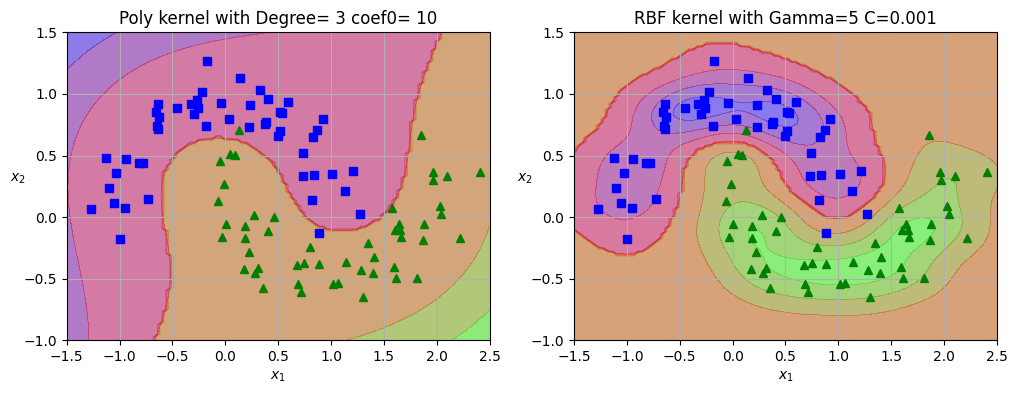

In [91]:
fig, axes= plt.subplots(1, 2, figsize= (12,4))


plt.sca(axes[0])
poly_kernel_svc_clf.set_params(svc__degree=3, svc__coef0= 10)
poly_kernel_svc_clf.fit(X, y)
plot_predictions(poly_kernel_svc_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title("Poly kernel with Degree= 3 coef0= 10")


plt.sca(axes[1])
plot_predictions(rbf_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title("RBF kernel with Gamma=5 C=0.001")

*Increasing  **Gamma** makes the bell shape curve narrower*

In [ ]:
def gaussian_rbf(x, landmark, gamma):
    return np.exp(-gamma * np.linalg.norm(x - landmark, axis=1)**2)

gamma = 0.3

x1s = np.linspace(-4.5, 4.5, 200).reshape(-1, 1)
x2s = gaussian_rbf(x1s, -2, gamma)
x3s = gaussian_rbf(x1s, 1, gamma)
